In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import *
from pprint import pprint
import mygene
import matplotlib.patches as mpatches

In [45]:
pnas_normal_tpm = pd.read_csv('data/reads/pnas_normal_tpm.txt', sep='\t')
pnas_tpm_96 = pd.read_csv('data/reads/pnas_tpm_96_nodup.txt', sep='\t', header=None)

pnas_tpm_96 = pnas_tpm_96.set_index(pnas_tpm_96.columns[0])

print(pnas_normal_tpm.shape)
print(pnas_tpm_96.shape)

n_normal = pnas_normal_tpm.shape[1]
n_cancer = pnas_tpm_96.shape[1]

data = pd.concat([pnas_normal_tpm, pnas_tpm_96], axis=1).T

print(len(data), n_normal + n_cancer)

(60675, 32)
(60675, 96)
128 128


In [46]:
pnas_normal_readcounts = pd.read_csv('data/reads/pnas_normal_readcounts.txt', sep='\t')
pnas_readcounts_96 = pd.read_csv('data/reads/pnas_readcounts_96_nodup.txt', sep='\t', header=None)

pnas_readcounts_96 = pnas_readcounts_96.set_index(pnas_readcounts_96.columns[0])

print(pnas_normal_readcounts.shape)
print(pnas_readcounts_96.shape)

n_normal = pnas_normal_readcounts.shape[1]
n_cancer = pnas_readcounts_96.shape[1]

reads = pd.concat([pnas_normal_readcounts, pnas_readcounts_96], axis=1).T

print(len(reads), n_normal + n_cancer)

(60680, 32)
(60680, 96)
128 128


In [47]:
common_genes = data.columns.intersection(reads.columns)

print(f"Common genes: {len(common_genes)}")

data = data[common_genes]
reads = reads[common_genes]

Common genes: 60675


In [48]:
min_sample_fraction = 0.20

min_samples = int(len(data) * min_sample_fraction)

gene_mask = ((data > 0.1).sum(axis=0) >= min_samples) & ((reads >= 6).sum(axis=0) >= min_samples)

filtered_data = data.loc[:, gene_mask]

print(filtered_data.shape)

(128, 15020)


In [49]:
mg = mygene.MyGeneInfo()

ensembl_ids = filtered_data.columns.tolist()

batch_size = 250
results = []

for i in range(0, len(ensembl_ids), batch_size):
    batch = ensembl_ids[i:i+batch_size]

    res = mg.querymany(
        batch,
        scopes="ensembl.gene",
        fields="symbol",
        species="human"
    )

    results.extend(res)
    
id_to_symbol = {}

for r in results:
    if "query" in r and "symbol" in r:
        id_to_symbol[r["query"]] = r["symbol"]

filtered_data = filtered_data.rename(columns=id_to_symbol)

1 input query terms found no hit:	['ENSG00000002079']
1 input query terms found no hit:	['ENSG00000069712']
1 input query terms found no hit:	['ENSG00000112096']
1 input query terms found no hit:	['ENSG00000116957']
1 input query terms found no hit:	['ENSG00000130723']
1 input query terms found no hit:	['ENSG00000133808']
1 input query terms found no hit:	['ENSG00000150076']
1 input query terms found no hit:	['ENSG00000155640']
1 input query terms found no hit:	['ENSG00000166748']
1 input query terms found no hit:	['ENSG00000168078']
1 input query terms found no hit:	['ENSG00000170647']
1 input query terms found dup hits:	[('ENSG00000175711', 2)]
1 input query terms found no hit:	['ENSG00000176659']
1 input query terms found no hit:	['ENSG00000179979']
1 input query terms found no hit:	['ENSG00000182230']
1 input query terms found no hit:	['ENSG00000185087']
1 input query terms found no hit:	['ENSG00000186354']
2 input query terms found no hit:	['ENSG00000188477', 'ENSG00000189144']
1 

In [50]:
filtered_data["cancer_status"] = [0] * n_normal + [1] * n_cancer

print(filtered_data)
print(filtered_data.shape)

       TSPAN6      SCYL3      FIRRM        CFH      FUCA2       GCLC  \
N1  26.432148   8.127159   8.035515  20.603770   8.583587  15.108249   
N2  17.260895   6.318156  20.406574   4.271368   6.228123   9.249458   
N3   0.000000  15.910242   0.000000   0.000000   0.000000  23.004230   
N4  69.795165  15.328639  17.681754   0.000000   0.000000   3.116715   
N5  19.331552  19.105460  11.019179  18.836099   0.000000   0.000000   
..        ...        ...        ...        ...        ...        ...   
92   0.000000  83.788404   3.020339   8.850761   0.000000   2.129548   
93  38.189128  18.172309  27.411791  35.438448   0.000000  15.916524   
94  15.608352   2.938248   1.694651  22.346922   0.000000  19.117537   
95  51.519267  14.547636   3.729079  16.391467  15.933703  22.348699   
96  30.805593  10.148436   7.804221  18.581376   0.000000  31.639464   

         NFYA      STPG1     NIPAL3      LAS1L  ...     PRNCR1  \
N1   6.290726  10.328341  21.244469  11.438639  ...  10.674348   
N2 

# Data Analytics and Visualization

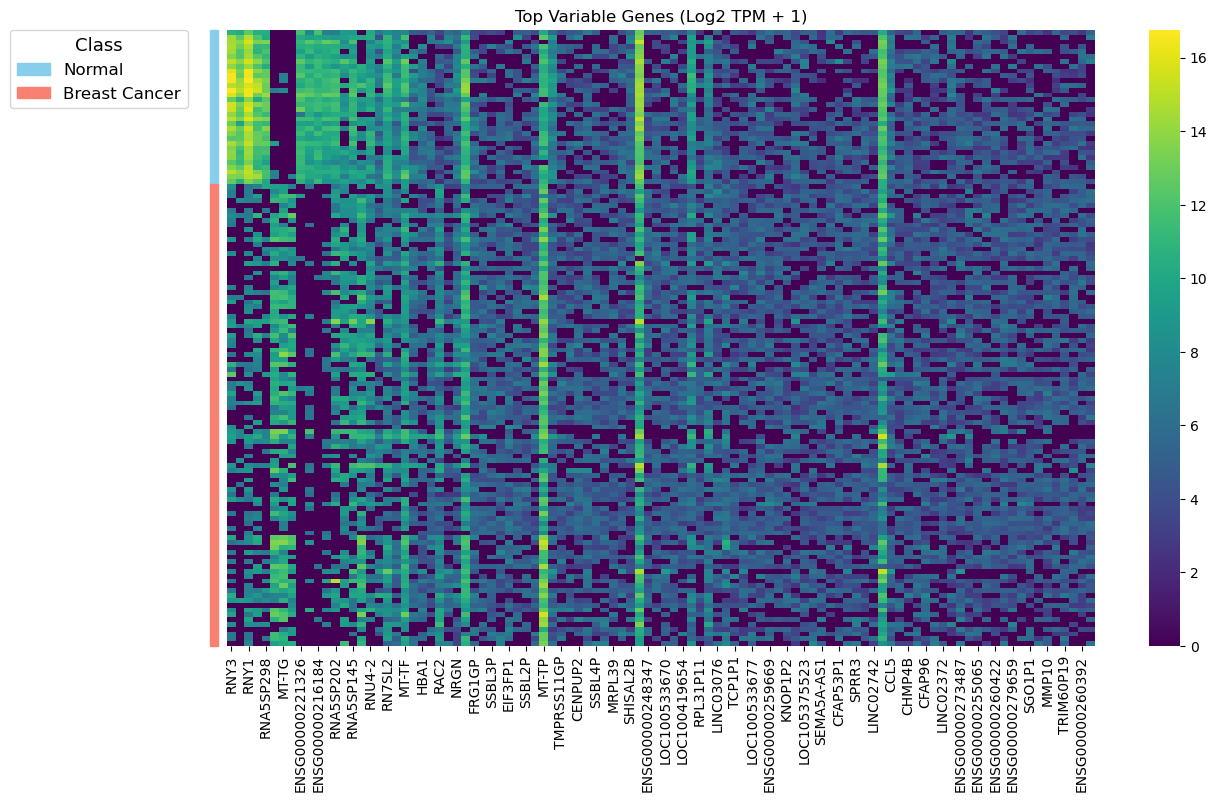

In [78]:
labels = filtered_data["cancer_status"]
expr = filtered_data.drop(columns=["cancer_status"])

data_T = expr.T

data_log = np.log2(data_T + 1)

top_genes = data_log.var(axis=1).sort_values(ascending=False).head(100)

heatmap_data = data_log.loc[top_genes.index]
labels_ordered = labels.loc[heatmap_data.T.index]

plt.figure(figsize=(14, 8))
ax = sns.heatmap(heatmap_data.T, cmap="viridis", yticklabels=False)

for i, c in enumerate(labels_ordered.map({0:"skyblue", 1:"salmon"})):
    ax.add_patch(
        plt.Rectangle(
            (-2, i), 1, 1,
            color=c,
            transform=ax.transData,
            clip_on=False
        )
    )
    
normal_patch = mpatches.Patch(color="skyblue", label="Normal")
cancer_patch = mpatches.Patch(color="salmon", label="Breast Cancer")

plt.legend(
    handles=[normal_patch, cancer_patch],
    title="Class",
    loc="upper left",
    bbox_to_anchor=(-0.25, 1),
    borderaxespad=0,
    fontsize=12,
    title_fontsize=13
)

plt.title("Top Variable Genes (Log2 TPM + 1)")
plt.show()

# Whole Dataset

In [79]:
scaler = MinMaxScaler()
X = filtered_data.drop(columns=["cancer_status"])
y = filtered_data["cancer_status"]
X_scaled = scaler.fit_transform(X)

## Logistic Regression

LR Model Cross-validation average score: 0.8738095238095237
Accuracy: 0.8846153846153846
Precision: 0.8571428571428571
Recall: 1.0
F1 Score: 0.923076923076923
ROC-AUC Score: 0.9652777777777778
Confusion Matrix:
[[ 5  3]
 [ 0 18]]


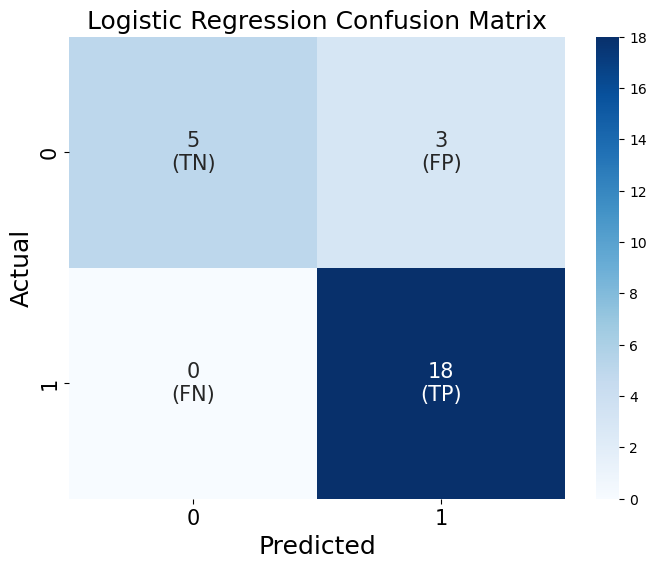

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

LR_Model = LogisticRegression()

LR_cross_scores = cross_val_score(LR_Model, X_train, y_train, cv=5)
print(f'LR Model Cross-validation average score: {LR_cross_scores.mean()}')

# Train the model
LR_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = LR_Model.predict(X_test)
y_pred_proba = LR_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
LR_accuracy = accuracy_score(y_test, y_pred)
LR_precision = precision_score(y_test, y_pred)
LR_recall = recall_score(y_test, y_pred)
LR_f1 = f1_score(y_test, y_pred)
LR_roc_auc = roc_auc_score(y_test, y_pred_proba)
LR_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {LR_accuracy}')
print(f'Precision: {LR_precision}')
print(f'Recall: {LR_recall}')
print(f'F1 Score: {LR_f1}')
print(f'ROC-AUC Score: {LR_roc_auc}')
print(f'Confusion Matrix:\n{LR_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_conf_matrix.shape[1])] 
                              for i in range(LR_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Randomized Search

In [82]:
print('Parameters currently in use:\n')
pprint(LR_Model.get_params())

Parameters currently in use:

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}


In [83]:
C = [0.001, 0.01, 0.1, 1, 10, 100]

penalty = ['l1', 'l2', 'elasticnet']

solver = ['liblinear', 'saga', 'lbfgs']

class_weight = [None, 'balanced']

max_iter = [100, 500, 1000, 2000]

l1_ratio = [0.1, 0.5, 0.9]

# Create the random grid
random_grid = {'C': C,
               'penalty': penalty,
               'solver': solver,
               'class_weight': class_weight,
               'max_iter': max_iter,
               'l1_ratio': l1_ratio}
pprint(random_grid)

{'C': [0.001, 0.01, 0.1, 1, 10, 100],
 'class_weight': [None, 'balanced'],
 'l1_ratio': [0.1, 0.5, 0.9],
 'max_iter': [100, 500, 1000, 2000],
 'penalty': ['l1', 'l2', 'elasticnet'],
 'solver': ['liblinear', 'saga', 'lbfgs']}


In [84]:
LR_random = RandomizedSearchCV(estimator = LR_Model, param_distributions = random_grid, n_iter=50, cv = 5, scoring='accuracy', verbose=10, random_state=42, n_jobs = -1)
LR_random.fit(X_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 3/5; 1/50] START C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga[CV 2/5; 2/50] START C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga

[CV 1/5; 1/50] START C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga
[CV 3/5; 2/50] START C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga
[CV 5/5; 1/50] START C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga
[CV 4/5; 1/50] START C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga
[CV 1/5; 2/50] START C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga
[CV 2/5; 1/50] START C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-

[CV 1/5; 2/50] END C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga;, score=0.905 total time=   0.4s
[CV 4/5; 2/50] START C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga
[CV 2/5; 2/50] END C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga;, score=0.905 total time=   0.5s
[CV 5/5; 2/50] START C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga
[CV 3/5; 2/50] END C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga;, score=0.950 total time=   0.5s
[CV 1/5; 3/50] START C=1, class_weight=None, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


[CV 4/5; 2/50] END C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga;, score=0.950 total time=   0.5s
[CV 2/5; 3/50] START C=1, class_weight=None, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga
[CV 5/5; 2/50] END C=0.01, class_weight=balanced, l1_ratio=0.1, max_iter=1000, penalty=l2, solver=saga;, score=0.800 total time=   0.5s
[CV 3/5; 3/50] START C=1, class_weight=None, l1_ratio=0.9, max_iter=1000, penalty=elasticnet, solver=saga
[CV 1/5; 1/50] END C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga;, score=0.857 total time=   1.4s
[CV 2/5; 1/50] END C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga;, score=0.905 total time=   1.5s
[CV 3/5; 1/50] END C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga;, score=1.000 total time=   1.5s
[CV 4/5; 1/50] END C=0.1, class_weight=balanced, l1_ratio=0.5, max_iter=1000, penalty=l2, solver=saga;, score=0

...

[CV 5/5; 42/50] END C=10, class_weight=None, l1_ratio=0.5, max_iter=100, penalty=l2, solver=saga;, score=0.800 total time=   1.7s
[CV 3/5; 50/50] END C=10, class_weight=None, l1_ratio=0.5, max_iter=500, penalty=l2, solver=lbfgs;, score=1.000 total time=   1.0s


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
110 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_scor

[CV 5/5; 19/50] END C=1, class_weight=None, l1_ratio=0.1, max_iter=1000, penalty=elasticnet, solver=saga;, score=0.900 total time=  17.7s
[CV 4/5; 19/50] END C=1, class_weight=None, l1_ratio=0.1, max_iter=1000, penalty=elasticnet, solver=saga;, score=0.950 total time=  17.9s


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=50, n_jobs=-1,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                        'class_weight': [None, 'balanced'],
                                        'l1_ratio': [0.1, 0.5, 0.9],
                                        'max_iter': [100, 500, 1000, 2000],
                                        'penalty': ['l1', 'l2', 'elasticnet'],
                                        'solver': ['liblinear', 'saga',
                                                   'lbfgs']},
                   random_state=42, scoring='accuracy', verbose=10)

In [85]:
LR_random.best_params_

{'solver': 'saga',
 'penalty': 'elasticnet',
 'max_iter': 500,
 'l1_ratio': 0.9,
 'class_weight': 'balanced',
 'C': 0.1}

In [86]:
best_LR = LR_random.best_estimator_

Accuracy: 0.9230769230769231
Precision: 0.9
Recall: 1.0
F1 Score: 0.9473684210526316
ROC-AUC Score: 1.0
Confusion Matrix:
[[ 6  2]
 [ 0 18]]


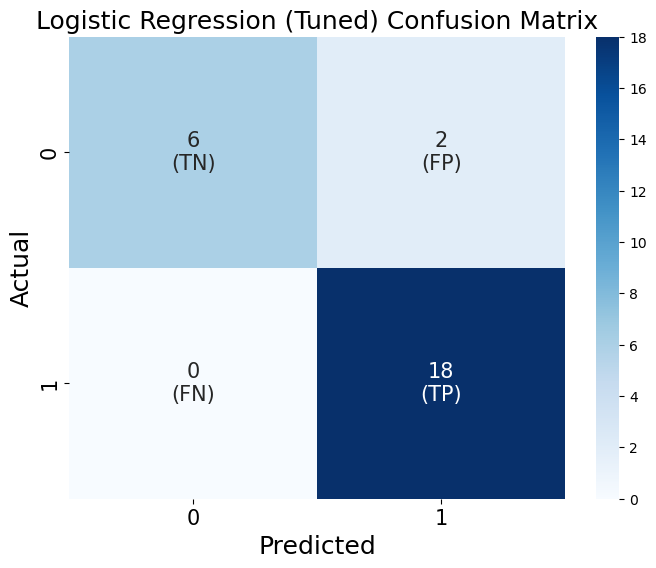

In [87]:
# Predict on the test set
y_pred = best_LR.predict(X_test)
y_pred_proba = best_LR.predict_proba(X_test)[:, 1]

# Evaluation metrics
LR_rand_accuracy = accuracy_score(y_test, y_pred)
LR_rand_precision = precision_score(y_test, y_pred)
LR_rand_recall = recall_score(y_test, y_pred)
LR_rand_f1 = f1_score(y_test, y_pred)
LR_rand_roc_auc = roc_auc_score(y_test, y_pred_proba)
LR_rand_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {LR_rand_accuracy}')
print(f'Precision: {LR_rand_precision}')
print(f'Recall: {LR_rand_recall}')
print(f'F1 Score: {LR_rand_f1}')
print(f'ROC-AUC Score: {LR_rand_roc_auc}')
print(f'Confusion Matrix:\n{LR_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_rand_conf_matrix.shape[1])] 
                              for i in range(LR_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Random Forest

RF Model Cross-validation average score: 0.9219047619047618
Accuracy: 0.8846153846153846
Precision: 0.8571428571428571
Recall: 1.0
F1 Score: 0.923076923076923
ROC-AUC Score: 0.9791666666666666
Confusion Matrix:
[[ 5  3]
 [ 0 18]]


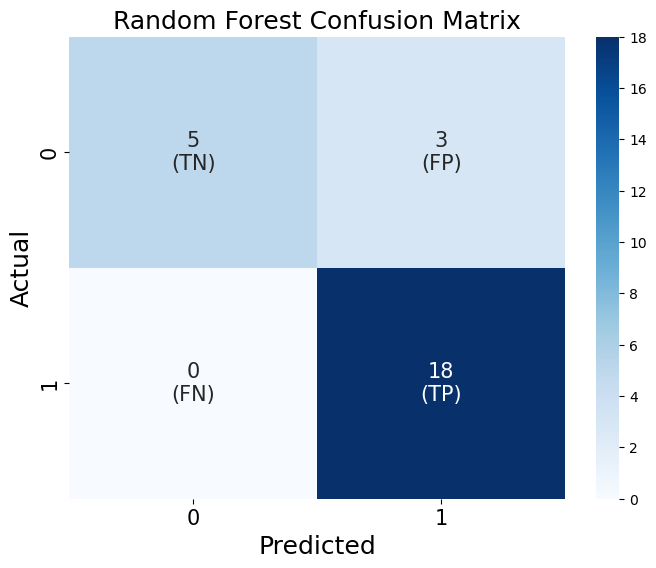

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

RF_Model = RandomForestClassifier()

RF_cross_scores = cross_val_score(RF_Model, X_train, y_train, cv=5)
print(f'RF Model Cross-validation average score: {RF_cross_scores.mean()}')

# Train the model
RF_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = RF_Model.predict(X_test)
y_pred_proba = RF_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
RF_accuracy = accuracy_score(y_test, y_pred)
RF_precision = precision_score(y_test, y_pred)
RF_recall = recall_score(y_test, y_pred)
RF_f1 = f1_score(y_test, y_pred)
RF_roc_auc = roc_auc_score(y_test, y_pred_proba)
RF_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {RF_accuracy}')
print(f'Precision: {RF_precision}')
print(f'Recall: {RF_recall}')
print(f'F1 Score: {RF_f1}')
print(f'ROC-AUC Score: {RF_roc_auc}')
print(f'Confusion Matrix:\n{RF_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_conf_matrix.shape[1])] 
                              for i in range(RF_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Randomized Search

In [89]:
print('Parameters currently in use:\n')
pprint(RF_Model.get_params())

Parameters currently in use:

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}


In [90]:
n_estimators = [100, 200, 500, 1000]

max_depth = [None, 10, 20, 50, 100]

min_samples_split = [2, 5, 10, 20]

min_samples_leaf = [1, 2, 4, 8]

max_features = ['sqrt', 'log2', None]

bootstrap = [True, False]

class_weight = [None, 'balanced', 'balanced_subsample']

criterion = ['gini', 'entropy', 'log_loss']

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'max_features': max_features,
               'bootstrap': bootstrap,
               'class_weight': class_weight,
               'criterion': criterion}
pprint(random_grid)

{'bootstrap': [True, False],
 'class_weight': [None, 'balanced', 'balanced_subsample'],
 'criterion': ['gini', 'entropy', 'log_loss'],
 'max_depth': [None, 10, 20, 50, 100],
 'max_features': ['sqrt', 'log2', None],
 'min_samples_leaf': [1, 2, 4, 8],
 'min_samples_split': [2, 5, 10, 20],
 'n_estimators': [100, 200, 500, 1000]}


In [91]:
RF_random = RandomizedSearchCV(estimator = RF_Model, param_distributions = random_grid, n_iter=50, cv = 5, scoring='accuracy', verbose=10, random_state=42, n_jobs = -1)
RF_random.fit(X_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5; 1/50] START bootstrap=False, class_weight=balanced_subsample, criterion=entropy, max_depth=20, max_features=sqrt, min_samples_leaf=8, min_samples_split=2, n_estimators=1000
[CV 2/5; 2/50] START bootstrap=True, class_weight=None, criterion=gini, max_depth=100, max_features=log2, min_samples_leaf=2, min_samples_split=20, n_estimators=100
[CV 3/5; 2/50] START bootstrap=True, class_weight=None, criterion=gini, max_depth=100, max_features=log2, min_samples_leaf=2, min_samples_split=20, n_estimators=100
[CV 5/5; 1/50] START bootstrap=False, class_weight=balanced_subsample, criterion=entropy, max_depth=20, max_features=sqrt, min_samples_leaf=8, min_samples_split=2, n_estimators=1000
[CV 2/5; 1/50] START bootstrap=False, class_weight=balanced_subsample, criterion=entropy, max_depth=20, max_features=sqrt, min_samples_leaf=8, min_samples_split=2, n_estimators=1000
[CV 3/5; 1/50] START bootstrap=False, class_weight=balanced_su

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'class_weight': [None, 'balanced',
                                                         'balanced_subsample'],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [None, 10, 20, 50, 100],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [100, 200, 500, 1000]},
                   random_state=42, scoring='accuracy', verbose=10)

In [92]:
RF_random.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': None,
 'max_depth': 50,
 'criterion': 'log_loss',
 'class_weight': None,
 'bootstrap': False}

In [93]:
best_RF = RF_random.best_estimator_

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC Score: 1.0
Confusion Matrix:
[[ 8  0]
 [ 0 18]]


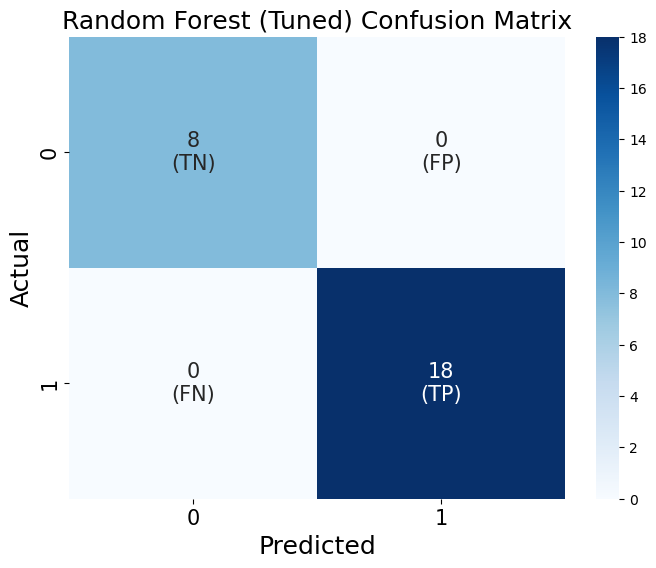

In [94]:
# Predict on the test set
y_pred = best_RF.predict(X_test)
y_pred_proba = best_RF.predict_proba(X_test)[:, 1]

# Evaluation metrics
RF_rand_accuracy = accuracy_score(y_test, y_pred)
RF_rand_precision = precision_score(y_test, y_pred)
RF_rand_recall = recall_score(y_test, y_pred)
RF_rand_f1 = f1_score(y_test, y_pred)
RF_rand_roc_auc = roc_auc_score(y_test, y_pred_proba)
RF_rand_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {RF_rand_accuracy}')
print(f'Precision: {RF_rand_precision}')
print(f'Recall: {RF_rand_recall}')
print(f'F1 Score: {RF_rand_f1}')
print(f'ROC-AUC Score: {RF_rand_roc_auc}')
print(f'Confusion Matrix:\n{RF_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_rand_conf_matrix.shape[1])] 
                              for i in range(RF_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Naive Bayes

NB Model Cross-validation average score: 0.9804761904761904
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC Score: 1.0
Confusion Matrix:
[[ 8  0]
 [ 0 18]]


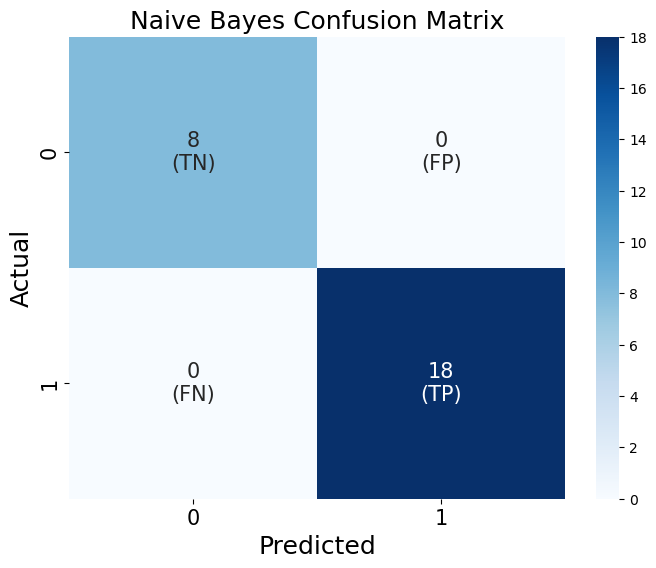

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

NB_Model = GaussianNB()

NB_cross_scores = cross_val_score(NB_Model, X_train, y_train, cv=5)
print(f'NB Model Cross-validation average score: {NB_cross_scores.mean()}')

# Train the model
NB_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = NB_Model.predict(X_test)
y_pred_proba = NB_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
NB_accuracy = accuracy_score(y_test, y_pred)
NB_precision = precision_score(y_test, y_pred)
NB_recall = recall_score(y_test, y_pred)
NB_f1 = f1_score(y_test, y_pred)
NB_roc_auc = roc_auc_score(y_test, y_pred_proba)
NB_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {NB_accuracy}')
print(f'Precision: {NB_precision}')
print(f'Recall: {NB_recall}')
print(f'F1 Score: {NB_f1}')
print(f'ROC-AUC Score: {NB_roc_auc}')
print(f'Confusion Matrix:\n{NB_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_conf_matrix.shape[1])] 
                              for i in range(NB_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Randomized Search

In [96]:
print('Parameters currently in use:\n')
pprint(NB_Model.get_params())

Parameters currently in use:

{'priors': None, 'var_smoothing': 1e-09}


In [97]:
var_smoothing = [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

# Create the random grid
random_grid = {'var_smoothing': var_smoothing}

pprint(random_grid)

{'var_smoothing': [1e-12,
                   1e-11,
                   1e-10,
                   1e-09,
                   1e-08,
                   1e-07,
                   1e-06,
                   1e-05,
                   0.0001,
                   0.001,
                   0.01,
                   0.1]}


In [98]:
NB_random = RandomizedSearchCV(estimator = NB_Model, param_distributions = random_grid, n_iter=50, cv = 5, scoring='accuracy', verbose=10, random_state=42, n_jobs = -1)
NB_random.fit(X_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


[CV 1/5; 1/12] START var_smoothing=1e-12........................................
[CV 5/5; 1/12] START var_smoothing=1e-12........................................
[CV 4/5; 1/12] START var_smoothing=1e-12........................................
[CV 3/5; 1/12] START var_smoothing=1e-12........................................
[CV 2/5; 1/12] START var_smoothing=1e-12........................................
[CV 3/5; 2/12] START var_smoothing=1e-11........................................
[CV 2/5; 2/12] START var_smoothing=1e-11........................................


/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV 1/5; 2/12] START var_smoothing=1e-11........................................
[CV 1/5; 1/12] END .........var_smoothing=1e-12;, score=1.000 total time=   0.1s
[CV 4/5; 2/12] START var_smoothing=1e-11........................................
[CV 4/5; 1/12] END .........var_smoothing=1e-12;, score=1.000 total time=   0.1s
[CV 5/5; 1/12] END .........var_smoothing=1e-12;, score=1.000 total time=   0.1s
[CV 1/5; 2/12] END .........var_smoothing=1e-11;, score=1.000 total time=   0.1s
[CV 3/5; 2/12] END .........var_smoothing=1e-11;, score=0.950 total time=   0.1s
[CV 2/5; 1/12] END .........var_smoothing=1e-12;, score=0.952 total time=   0.1s
[CV 4/5; 2/12] END .........var_smoothing=1e-11;, score=1.000 total time=   0.1s
[CV 5/5; 3/12] START var_smoothing=1e-10........................................
[CV 2/5; 3/12] START var_smoothing=1e-10........................................
[CV 5/5; 2/12] START var_smoothing=1e-11........................................
[CV 3/5; 3/12] START var_smo

RandomizedSearchCV(cv=5, estimator=GaussianNB(), n_iter=50, n_jobs=-1,
                   param_distributions={'var_smoothing': [1e-12, 1e-11, 1e-10,
                                                          1e-09, 1e-08, 1e-07,
                                                          1e-06, 1e-05, 0.0001,
                                                          0.001, 0.01, 0.1]},
                   random_state=42, scoring='accuracy', verbose=10)

In [99]:
NB_random.best_params_

{'var_smoothing': 1e-06}

In [100]:
best_NB = NB_random.best_estimator_

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC Score: 1.0
Confusion Matrix:
[[ 8  0]
 [ 0 18]]


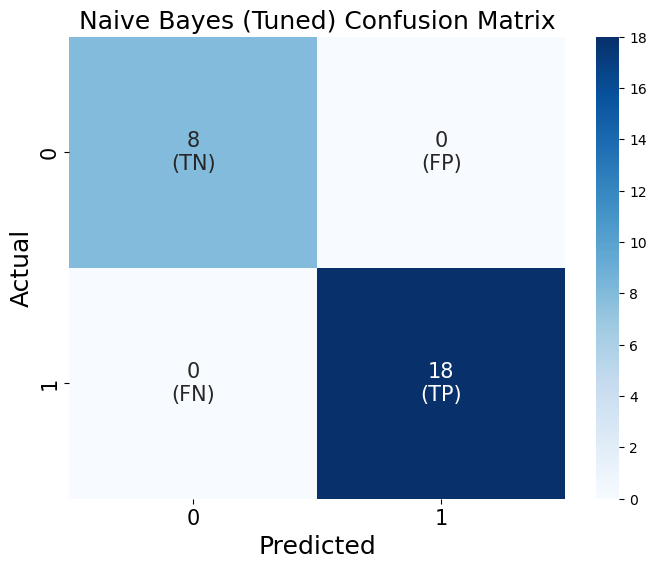

In [101]:
# Predict on the test set
y_pred = best_NB.predict(X_test)
y_pred_proba = best_NB.predict_proba(X_test)[:, 1]

# Evaluation metrics
NB_rand_accuracy = accuracy_score(y_test, y_pred)
NB_rand_precision = precision_score(y_test, y_pred)
NB_rand_recall = recall_score(y_test, y_pred)
NB_rand_f1 = f1_score(y_test, y_pred)
NB_rand_roc_auc = roc_auc_score(y_test, y_pred_proba)
NB_rand_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {NB_rand_accuracy}')
print(f'Precision: {NB_rand_precision}')
print(f'Recall: {NB_rand_recall}')
print(f'F1 Score: {NB_rand_f1}')
print(f'ROC-AUC Score: {NB_rand_roc_auc}')
print(f'Confusion Matrix:\n{NB_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_rand_conf_matrix.shape[1])] 
                              for i in range(NB_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Support Vector Machine

SVM Model Cross-validation average score: 0.7945454545454547
Accuracy: 0.8076923076923077
Precision: 0.782608695652174
Recall: 1.0
F1 Score: 0.878048780487805
ROC-AUC Score: 0.9722222222222222
Confusion Matrix:
[[ 3  5]
 [ 0 18]]


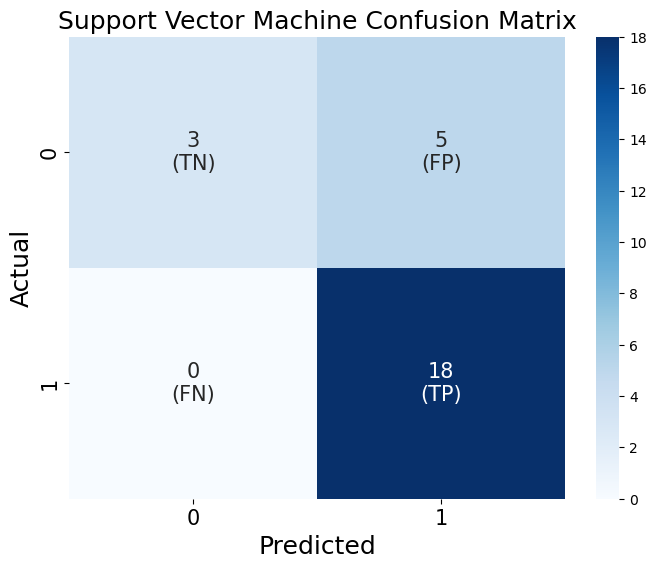

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

SVM_Model = SVC(probability=True)

SVM_cross_scores = cross_val_score(SVM_Model, X_train, y_train, cv=10)
print(f'SVM Model Cross-validation average score: {SVM_cross_scores.mean()}')

# Train the model
SVM_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = SVM_Model.predict(X_test)
y_pred_proba = SVM_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
SVM_accuracy = accuracy_score(y_test, y_pred)
SVM_precision = precision_score(y_test, y_pred)
SVM_recall = recall_score(y_test, y_pred)
SVM_f1 = f1_score(y_test, y_pred)
SVM_roc_auc = roc_auc_score(y_test, y_pred_proba)
SVM_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {SVM_accuracy}')
print(f'Precision: {SVM_precision}')
print(f'Recall: {SVM_recall}')
print(f'F1 Score: {SVM_f1}')
print(f'ROC-AUC Score: {SVM_roc_auc}')
print(f'Confusion Matrix:\n{SVM_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_conf_matrix.shape[1])] 
                              for i in range(SVM_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Support Vector Machine Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Randomized Search

In [103]:
print('Parameters currently in use:\n')
pprint(SVM_Model.get_params())

Parameters currently in use:

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}


In [104]:
C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

kernel = ['linear', 'rbf', 'poly', 'sigmoid']

gamma = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

degree = [2, 3, 4, 5]

class_weight = [None, 'balanced']

probability = [True]

# Create the random grid
random_grid = {'C': C,
               'kernel': kernel,
               'gamma': gamma,
               'degree': degree,
               'class_weight': class_weight,
               'probability': probability}
pprint(random_grid)

{'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
 'class_weight': [None, 'balanced'],
 'degree': [2, 3, 4, 5],
 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
 'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
 'probability': [True]}


In [105]:
SVM_random = RandomizedSearchCV(estimator = SVM_Model, param_distributions = random_grid, n_iter=50, cv = 5, scoring='accuracy', verbose=10, random_state=42, n_jobs = -1)
SVM_random.fit(X_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 3/5; 1/50] START C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True
[CV 1/5; 1/50] START C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True
[CV 2/5; 1/50] START C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True
[CV 4/5; 1/50] START C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True
[CV 5/5; 1/50] START C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True
[CV 1/5; 2/50] START C=0.01, class_weight=None, degree=4, gamma=1, kernel=rbf, probability=True
[CV 2/5; 2/50] START C=0.01, class_weight=None, degree=4, gamma=1, kernel=rbf, probability=True
[CV 3/5; 2/50] START C=0.01, class_weight=None, degree=4, gamma=1, kernel=rbf, probability=True
[CV 2/5; 1/50] END C=0.01, class_weight=None, degree=5, gamma=1, kernel=poly, probability=True;, score=0.905 total time=   0.7s
[CV 3/5; 1/50] END C=0.01, class_weig

RandomizedSearchCV(cv=5, estimator=SVC(probability=True), n_iter=50, n_jobs=-1,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100,
                                              1000],
                                        'class_weight': [None, 'balanced'],
                                        'degree': [2, 3, 4, 5],
                                        'gamma': ['scale', 'auto', 0.001, 0.01,
                                                  0.1, 1],
                                        'kernel': ['linear', 'rbf', 'poly',
                                                   'sigmoid'],
                                        'probability': [True]},
                   random_state=42, scoring='accuracy', verbose=10)

In [106]:
SVM_random.best_params_

{'probability': True,
 'kernel': 'poly',
 'gamma': 1,
 'degree': 3,
 'class_weight': None,
 'C': 0.1}

In [107]:
best_SVM = SVM_random.best_estimator_

Accuracy: 0.8461538461538461
Precision: 0.85
Recall: 0.9444444444444444
F1 Score: 0.8947368421052632
ROC-AUC Score: 0.9444444444444444
Confusion Matrix:
[[ 5  3]
 [ 1 17]]


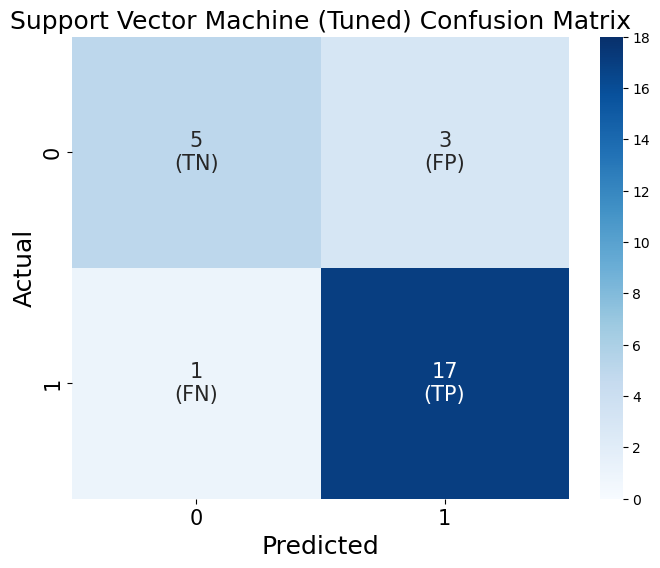

In [114]:
# Predict on the test set
y_pred = best_SVM.predict(X_test)
y_pred_proba = best_SVM.predict_proba(X_test)[:, 1]

# Evaluation metrics
SVM_rand_accuracy = accuracy_score(y_test, y_pred)
SVM_rand_precision = precision_score(y_test, y_pred)
SVM_rand_recall = recall_score(y_test, y_pred)
SVM_rand_f1 = f1_score(y_test, y_pred)
SVM_rand_roc_auc = roc_auc_score(y_test, y_pred_proba)
SVM_rand_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {SVM_rand_accuracy}')
print(f'Precision: {SVM_rand_precision}')
print(f'Recall: {SVM_rand_recall}')
print(f'F1 Score: {SVM_rand_f1}')
print(f'ROC-AUC Score: {SVM_rand_roc_auc}')
print(f'Confusion Matrix:\n{SVM_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_rand_conf_matrix.shape[1])] 
                              for i in range(SVM_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Support Vector Machine (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Validation

In [109]:
validation_df = pd.read_csv('data/reads/validation_exon_tpm', sep='\t').T


print(validation_df)
print(validation_df.shape)

            ENSG00000223972  ENSG00000227232  ENSG00000278267  \
BCSC_S5_01         0.000000         0.000000              0.0   
BCSC_S5_02         0.000000        10.710056              0.0   
BCSC_S5_03         0.000000         9.077035              0.0   
BCSC_S5_04         0.000000         0.000000              0.0   
BCSC_S5_05        14.462475         0.000000              0.0   
...                     ...              ...              ...   
BCSC_S6_71         0.000000         7.122692              0.0   
BCSC_S6_72         0.000000         0.000000              0.0   
BCSC_S6_73        13.779037         0.000000              0.0   
BCSC_S6_74         0.000000         0.000000              0.0   
BCSC_S6_75         0.000000         0.000000              0.0   

            ENSG00000243485  ENSG00000274890  ENSG00000237613  \
BCSC_S5_01         0.000000              0.0              0.0   
BCSC_S5_02         0.000000              0.0              0.0   
BCSC_S5_03         0.000

In [113]:
filtered_val_df = validation_df.loc[:, gene_mask]

print(filtered_val_df.shape)

filtered_val_df = filtered_val_df.rename(columns=id_to_symbol)

(161, 15020)


In [115]:
bc_meta = pd.read_excel('data/validation_bc_meta.xlsx')
normal_meta = pd.read_excel('data/validation_normal_meta.xlsx')

print(bc_meta.head())

bc_samples = bc_meta["Mapping ID"]
normal_samples = normal_meta["Mapping ID"]

filtered_val_df["cancer_status"] = np.nan

filtered_val_df.loc[
    filtered_val_df.index.isin(bc_samples),
    "cancer_status"
] = 1

filtered_val_df.loc[
    filtered_val_df.index.isin(normal_samples),
    "cancer_status"
] = 0

filtered_val_df["cancer_status"] = filtered_val_df["cancer_status"].astype(int)

print(filtered_val_df)
print(filtered_val_df.shape)


   Mapping ID  Age at Sample collection  Gender  \
0  BCSC_S5_40                        29  Female   
1  BCSC_S5_41                        29  Female   
2  BCSC_S5_42                        33  Female   
3  BCSC_S5_43                        37  Female   
4  BCSC_S5_44                        39  Female   

  Recurrence Staus at the time of collection  
0                               Nonrecurrent  
1                               Nonrecurrent  
2                               Nonrecurrent  
3                               Nonrecurrent  
4                               Nonrecurrent  
              MTND2P28    MTATP6P1  LINC01409  LINC01128      NOC2L  \
BCSC_S5_01  378.525087  967.156609   2.652946   3.091088  13.212045   
BCSC_S5_02  194.032572  382.448090  13.113364  12.223262  26.122560   
BCSC_S5_03  187.939842  684.283168   6.668339   9.064575  15.497657   
BCSC_S5_04  221.984651  324.842577   7.637615  11.123739  20.920019   
BCSC_S5_05  156.226594  294.771154  11.370489   3.974508

In [116]:
X_val = filtered_val_df.drop(columns=["cancer_status"])
y_val = filtered_val_df["cancer_status"]

X_val = X_val[X.columns]

print((X_val.columns == X.columns).all())

X_val_scaled = scaler.fit_transform(X_val)

True


### Default

#### Logistic Regression

Accuracy: 0.5031055900621118
Precision: 0.5094339622641509
Recall: 0.9759036144578314
F1 Score: 0.6694214876033058
ROC-AUC Score: 0.6515291936978685
Confusion Matrix:
[[ 0 78]
 [ 2 81]]


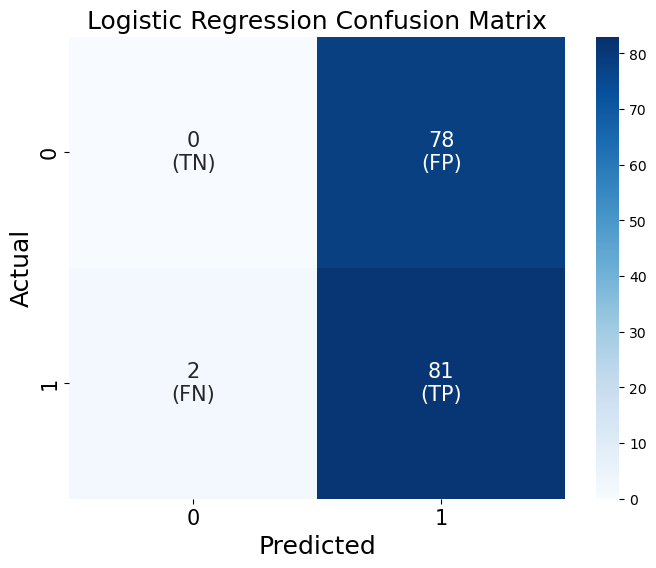

In [117]:
# Predict on the validation set
y_pred = LR_Model.predict(X_val_scaled)
y_pred_proba = LR_Model.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
LR_accuracy = accuracy_score(y_val, y_pred)
LR_precision = precision_score(y_val, y_pred)
LR_recall = recall_score(y_val, y_pred)
LR_f1 = f1_score(y_val, y_pred)
LR_roc_auc = roc_auc_score(y_val, y_pred_proba)
LR_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {LR_accuracy}')
print(f'Precision: {LR_precision}')
print(f'Recall: {LR_recall}')
print(f'F1 Score: {LR_f1}')
print(f'ROC-AUC Score: {LR_roc_auc}')
print(f'Confusion Matrix:\n{LR_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_conf_matrix.shape[1])] 
                              for i in range(LR_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Random Forest

Accuracy: 0.5093167701863354
Precision: 0.5131578947368421
Recall: 0.9397590361445783
F1 Score: 0.6638297872340426
ROC-AUC Score: 0.5878900216249614
Confusion Matrix:
[[ 4 74]
 [ 5 78]]


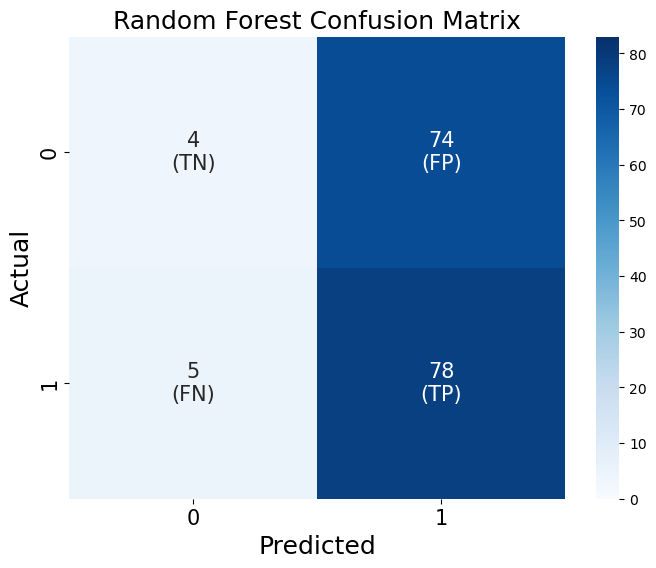

In [118]:
# Predict on the validation set
y_pred = RF_Model.predict(X_val_scaled)
y_pred_proba = RF_Model.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
RF_accuracy = accuracy_score(y_val, y_pred)
RF_precision = precision_score(y_val, y_pred)
RF_recall = recall_score(y_val, y_pred)
RF_f1 = f1_score(y_val, y_pred)
RF_roc_auc = roc_auc_score(y_val, y_pred_proba)
RF_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {RF_accuracy}')
print(f'Precision: {RF_precision}')
print(f'Recall: {RF_recall}')
print(f'F1 Score: {RF_f1}')
print(f'ROC-AUC Score: {RF_roc_auc}')
print(f'Confusion Matrix:\n{RF_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_conf_matrix.shape[1])] 
                              for i in range(RF_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Naive Bayes

Accuracy: 0.5217391304347826
Precision: 0.5194805194805194
Recall: 0.963855421686747
F1 Score: 0.6751054852320675
ROC-AUC Score: 0.5075687364843992
Confusion Matrix:
[[ 4 74]
 [ 3 80]]


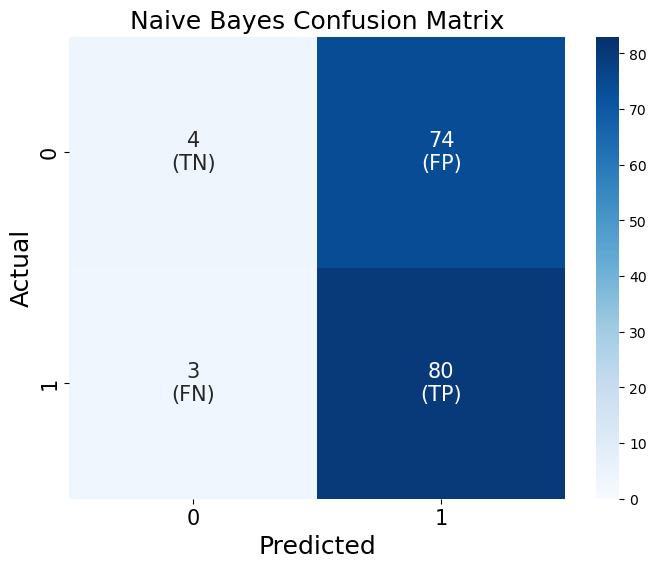

In [119]:
# Predict on the validation set
y_pred = NB_Model.predict(X_val_scaled)
y_pred_proba = NB_Model.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
NB_accuracy = accuracy_score(y_val, y_pred)
NB_precision = precision_score(y_val, y_pred)
NB_recall = recall_score(y_val, y_pred)
NB_f1 = f1_score(y_val, y_pred)
NB_roc_auc = roc_auc_score(y_val, y_pred_proba)
NB_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {NB_accuracy}')
print(f'Precision: {NB_precision}')
print(f'Recall: {NB_recall}')
print(f'F1 Score: {NB_f1}')
print(f'ROC-AUC Score: {NB_roc_auc}')
print(f'Confusion Matrix:\n{NB_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_conf_matrix.shape[1])] 
                              for i in range(NB_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Support Vector Machine

Accuracy: 0.5093167701863354
Precision: 0.5125
Recall: 0.9879518072289156
F1 Score: 0.6748971193415637
ROC-AUC Score: 0.5892801977139326
Confusion Matrix:
[[ 0 78]
 [ 1 82]]


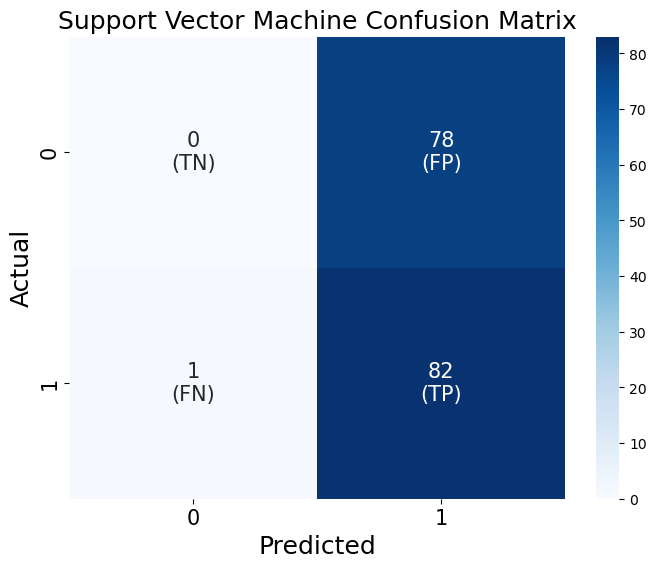

In [120]:
# Predict on the validation set
y_pred = SVM_Model.predict(X_val_scaled)
y_pred_proba = SVM_Model.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
SVM_accuracy = accuracy_score(y_val, y_pred)
SVM_precision = precision_score(y_val, y_pred)
SVM_recall = recall_score(y_val, y_pred)
SVM_f1 = f1_score(y_val, y_pred)
SVM_roc_auc = roc_auc_score(y_val, y_pred_proba)
SVM_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {SVM_accuracy}')
print(f'Precision: {SVM_precision}')
print(f'Recall: {SVM_recall}')
print(f'F1 Score: {SVM_f1}')
print(f'ROC-AUC Score: {SVM_roc_auc}')
print(f'Confusion Matrix:\n{SVM_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_conf_matrix.shape[1])] 
                              for i in range(SVM_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Support Vector Machine Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Hyperparameter Tuned

#### Logistic Regression

Accuracy: 0.5093167701863354
Precision: 0.5125
Recall: 0.9879518072289156
F1 Score: 0.6748971193415637
ROC-AUC Score: 0.5129749768303985
Confusion Matrix:
[[ 0 78]
 [ 1 82]]


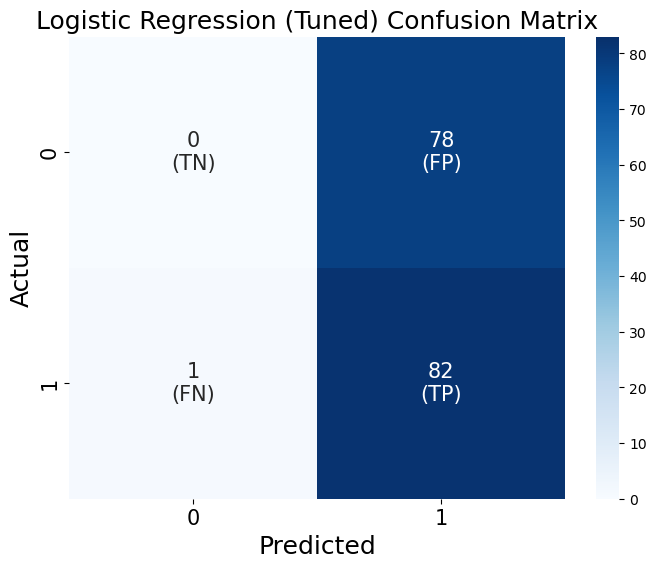

In [121]:
# Predict on the validation set
y_pred = best_LR.predict(X_val_scaled)
y_pred_proba = best_LR.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
LR_rand_accuracy = accuracy_score(y_val, y_pred)
LR_rand_precision = precision_score(y_val, y_pred)
LR_rand_recall = recall_score(y_val, y_pred)
LR_rand_f1 = f1_score(y_val, y_pred)
LR_rand_roc_auc = roc_auc_score(y_val, y_pred_proba)
LR_rand_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {LR_rand_accuracy}')
print(f'Precision: {LR_rand_precision}')
print(f'Recall: {LR_rand_recall}')
print(f'F1 Score: {LR_rand_f1}')
print(f'ROC-AUC Score: {LR_rand_roc_auc}')
print(f'Confusion Matrix:\n{LR_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_rand_conf_matrix.shape[1])] 
                              for i in range(LR_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Random Forest

Accuracy: 0.453416149068323
Precision: 0.4778761061946903
Recall: 0.6506024096385542
F1 Score: 0.5510204081632654
ROC-AUC Score: 0.5177633611368551
Confusion Matrix:
[[19 59]
 [29 54]]


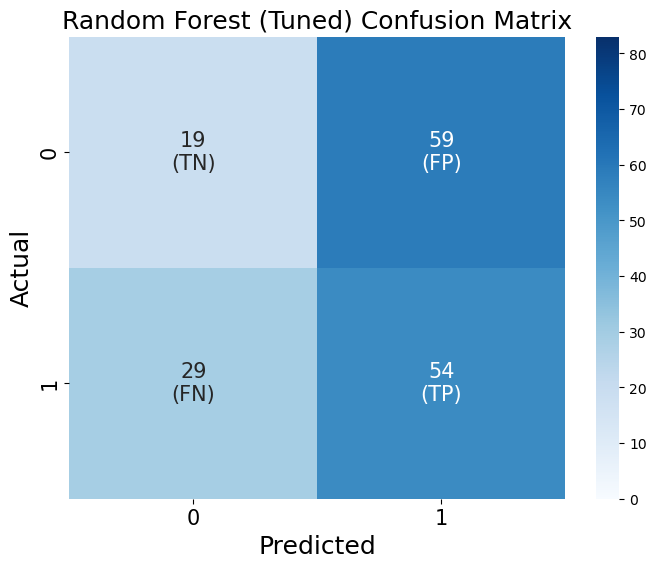

In [122]:
# Predict on the validation set
y_pred = best_RF.predict(X_val_scaled)
y_pred_proba = best_RF.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
RF_rand_accuracy = accuracy_score(y_val, y_pred)
RF_rand_precision = precision_score(y_val, y_pred)
RF_rand_recall = recall_score(y_val, y_pred)
RF_rand_f1 = f1_score(y_val, y_pred)
RF_rand_roc_auc = roc_auc_score(y_val, y_pred_proba)
RF_rand_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {RF_rand_accuracy}')
print(f'Precision: {RF_rand_precision}')
print(f'Recall: {RF_rand_recall}')
print(f'F1 Score: {RF_rand_f1}')
print(f'ROC-AUC Score: {RF_rand_roc_auc}')
print(f'Confusion Matrix:\n{RF_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_rand_conf_matrix.shape[1])] 
                              for i in range(RF_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Naive Bayes

Accuracy: 0.5217391304347826
Precision: 0.5194805194805194
Recall: 0.963855421686747
F1 Score: 0.6751054852320675
ROC-AUC Score: 0.5075687364843992
Confusion Matrix:
[[ 4 74]
 [ 3 80]]


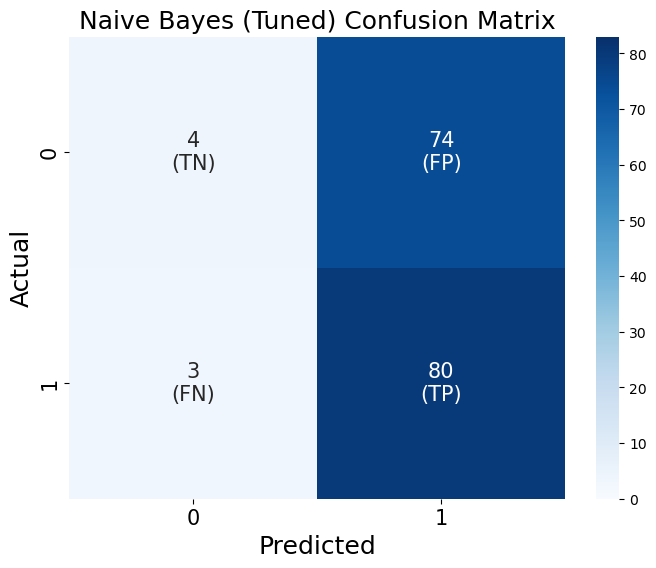

In [123]:
# Predict on the validation set
y_pred = best_NB.predict(X_val_scaled)
y_pred_proba = best_NB.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
NB_rand_accuracy = accuracy_score(y_val, y_pred)
NB_rand_precision = precision_score(y_val, y_pred)
NB_rand_recall = recall_score(y_val, y_pred)
NB_rand_f1 = f1_score(y_val, y_pred)
NB_rand_roc_auc = roc_auc_score(y_val, y_pred_proba)
NB_rand_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {NB_rand_accuracy}')
print(f'Precision: {NB_rand_precision}')
print(f'Recall: {NB_rand_recall}')
print(f'F1 Score: {NB_rand_f1}')
print(f'ROC-AUC Score: {NB_rand_roc_auc}')
print(f'Confusion Matrix:\n{NB_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_rand_conf_matrix.shape[1])] 
                              for i in range(NB_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### Support Vector Machine

Accuracy: 0.5093167701863354
Precision: 0.5126582278481012
Recall: 0.9759036144578314
F1 Score: 0.6721991701244813
ROC-AUC Score: 0.6138399752857585
Confusion Matrix:
[[ 1 77]
 [ 2 81]]


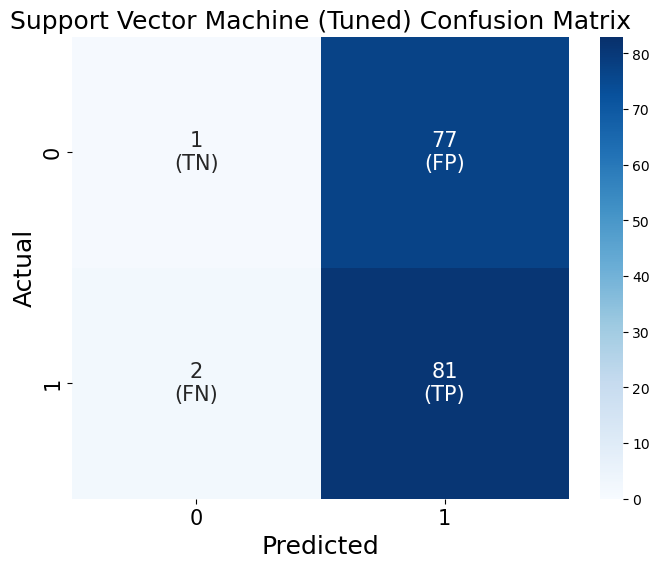

In [124]:
# Predict on the validation set
y_pred = best_SVM.predict(X_val_scaled)
y_pred_proba = best_SVM.predict_proba(X_val_scaled)[:, 1]

# Evaluation metrics
SVM_rand_accuracy = accuracy_score(y_val, y_pred)
SVM_rand_precision = precision_score(y_val, y_pred)
SVM_rand_recall = recall_score(y_val, y_pred)
SVM_rand_f1 = f1_score(y_val, y_pred)
SVM_rand_roc_auc = roc_auc_score(y_val, y_pred_proba)
SVM_rand_conf_matrix = confusion_matrix(y_val, y_pred)

print(f'Accuracy: {SVM_rand_accuracy}')
print(f'Precision: {SVM_rand_precision}')
print(f'Recall: {SVM_rand_recall}')
print(f'F1 Score: {SVM_rand_f1}')
print(f'ROC-AUC Score: {SVM_rand_roc_auc}')
print(f'Confusion Matrix:\n{SVM_rand_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_rand_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_rand_conf_matrix.shape[1])] 
                              for i in range(SVM_rand_conf_matrix.shape[0])])

value, counts = np.unique(y_val, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_rand_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Support Vector Machine (Tuned) Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Data Visualization

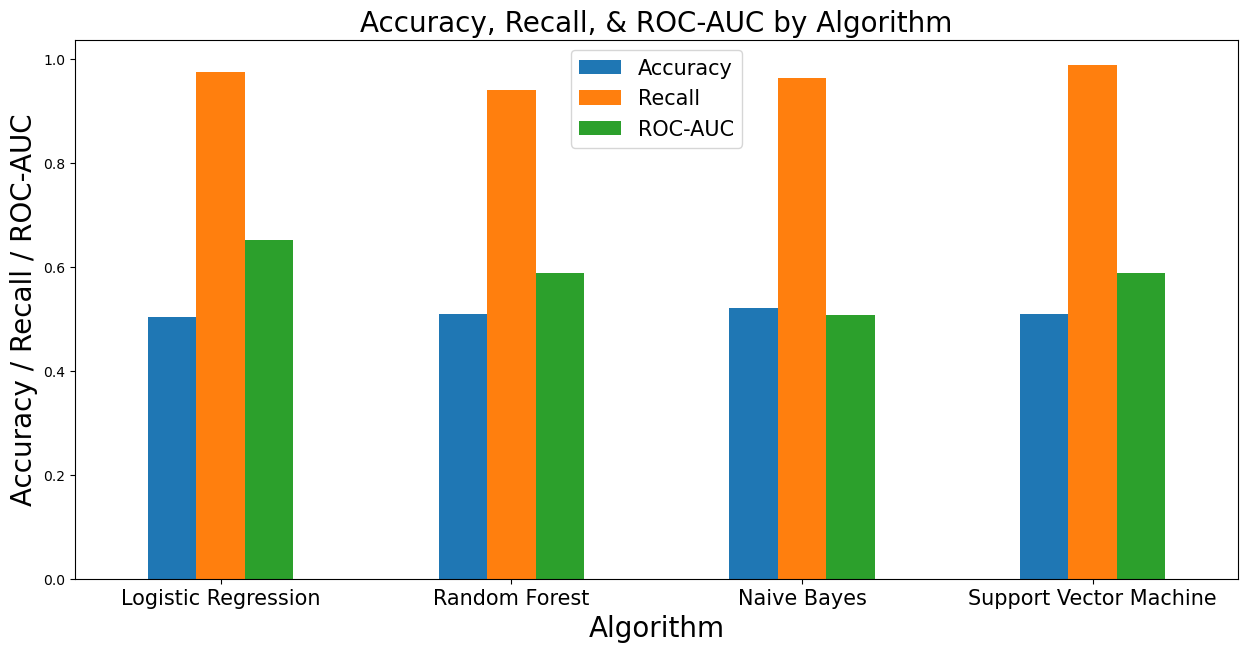

In [125]:
data = {
    "Logistic Regression": [
        LR_accuracy,
        LR_recall,
        LR_roc_auc,
    ],
    "Random Forest": [
        RF_accuracy,
        RF_recall,
        RF_roc_auc,
    ],
    "Naive Bayes": [
        NB_accuracy,
        NB_recall,
        NB_roc_auc,
    ],
    "Support Vector Machine": [
        SVM_accuracy,
        SVM_recall,
        SVM_roc_auc,
    ],
    
}

data_df = pd.DataFrame(data=data).T.reset_index()
data_df.columns = ["Algorithm", "Accuracy", "Recall", "ROC-AUC"]

# creating the bar plot
data_df.plot(kind="bar", x="Algorithm", y=["Accuracy", "Recall", "ROC-AUC"], figsize=(15, 7), rot=0)
plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("Accuracy / Recall / ROC-AUC", fontsize=20)
plt.title("Accuracy, Recall, & ROC-AUC by Algorithm", fontsize=20)
plt.xticks(fontsize=15)
plt.legend(fontsize=15)

plt.show()

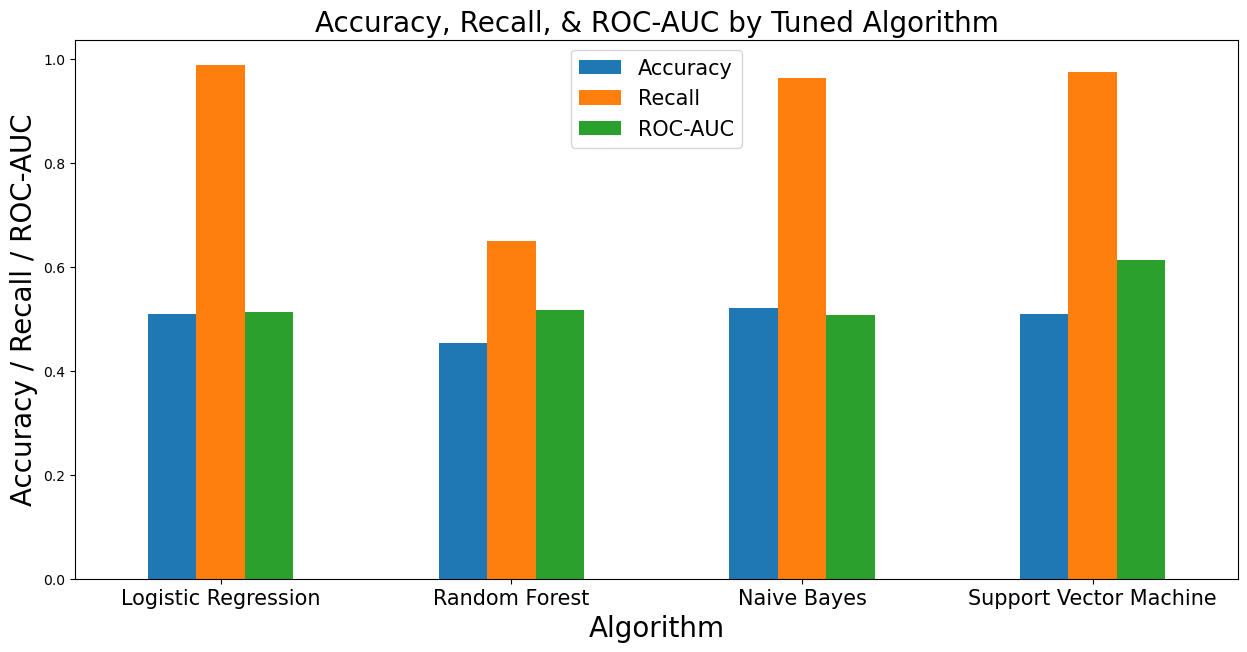

In [126]:
data = {
    "Logistic Regression": [
        LR_rand_accuracy,
        LR_rand_recall,
        LR_rand_roc_auc,
    ],
    "Random Forest": [
        RF_rand_accuracy,
        RF_rand_recall,
        RF_rand_roc_auc,
    ],
    "Naive Bayes": [
        NB_rand_accuracy,
        NB_rand_recall,
        NB_rand_roc_auc,
    ],
    "Support Vector Machine": [
        SVM_rand_accuracy,
        SVM_rand_recall,
        SVM_rand_roc_auc,
    ],
    
}

data_df = pd.DataFrame(data=data).T.reset_index()
data_df.columns = ["Algorithm", "Accuracy", "Recall", "ROC-AUC"]

# creating the bar plot
data_df.plot(kind="bar", x="Algorithm", y=["Accuracy", "Recall", "ROC-AUC"], figsize=(15, 7), rot=0)
plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("Accuracy / Recall / ROC-AUC", fontsize=20)
plt.title("Accuracy, Recall, & ROC-AUC by Tuned Algorithm", fontsize=20)
plt.xticks(fontsize=15)
plt.legend(fontsize=15)

plt.show()

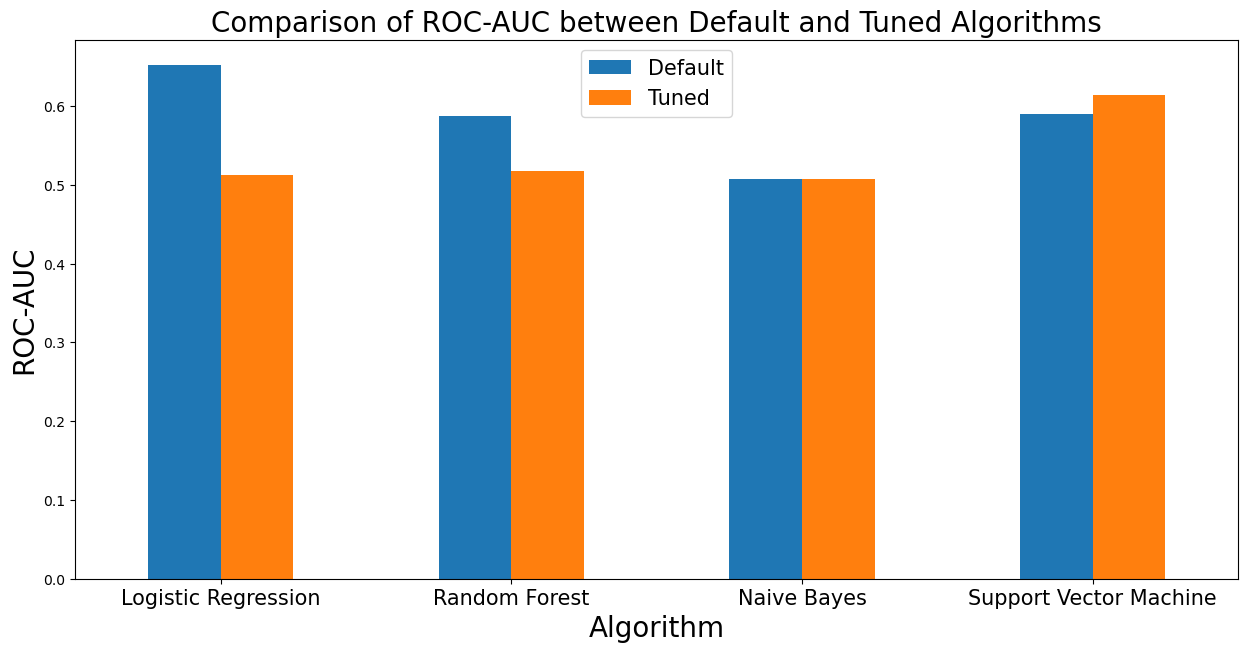

In [127]:
data = {
    "Logistic Regression": [
        LR_roc_auc,
        LR_rand_roc_auc,
    ],
    "Random Forest": [
        RF_roc_auc,
        RF_rand_roc_auc,
    ],
    "Naive Bayes": [
        NB_roc_auc,
        NB_rand_roc_auc,
    ],
    "Support Vector Machine": [
        SVM_roc_auc,
        SVM_rand_roc_auc,
    ],
    
}

data_df = pd.DataFrame(data=data).T.reset_index()
data_df.columns = ["Algorithm", "Default", "Tuned"]

# creating the bar plot
data_df.plot(kind="bar", x="Algorithm", y=["Default", "Tuned"], figsize=(15, 7), rot=0)
plt.xlabel("Algorithm", fontsize=20)
plt.ylabel("ROC-AUC", fontsize=20)
plt.title("Comparison of ROC-AUC between Default and Tuned Algorithms", fontsize=20)
plt.xticks(fontsize=15)
plt.legend(fontsize=15)

plt.show()

# Breast Cancer Gene Subset